In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
DATA_PATH = "../data/raw/"

customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
geolocations = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
category_translations = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("Todos os datasets carregados com sucesso!")

Todos os datasets carregados com sucesso!


In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocations": geolocations,
    "category_translations": category_translations
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} linhas, {df.shape[1]} colunas")

customers: 99441 linhas, 5 colunas
orders: 99441 linhas, 8 colunas
order_items: 112650 linhas, 7 colunas
payments: 103886 linhas, 5 colunas
reviews: 99224 linhas, 7 colunas
products: 32951 linhas, 9 colunas
sellers: 3095 linhas, 4 colunas
geolocations: 1000163 linhas, 5 colunas
category_translations: 71 linhas, 2 colunas


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
print("=== VALORES NULOS ===\n")
for name, df in datasets.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"--- {name} ---")
        print(nulos)
        print()

=== VALORES NULOS ===

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



In [6]:
print("=== LINHAS DUPLICADAS ===\n")
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f"{name}: {dup} linhas duplicadas")

=== LINHAS DUPLICADAS ===

customers: 0 linhas duplicadas
orders: 0 linhas duplicadas
order_items: 0 linhas duplicadas
payments: 0 linhas duplicadas
reviews: 0 linhas duplicadas
products: 0 linhas duplicadas
sellers: 0 linhas duplicadas
geolocations: 261831 linhas duplicadas
category_translations: 0 linhas duplicadas


In [7]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [8]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [9]:
print(f"Período dos pedidos: {orders['order_purchase_timestamp'].min()} a {orders['order_purchase_timestamp'].max()}")

Período dos pedidos: 2016-09-04 21:15:19 a 2018-10-17 17:30:18


In [10]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
delivered = orders[orders['order_status'] == 'delivered'].copy()

delivered['delivery_time_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

delivered['delivery_time_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

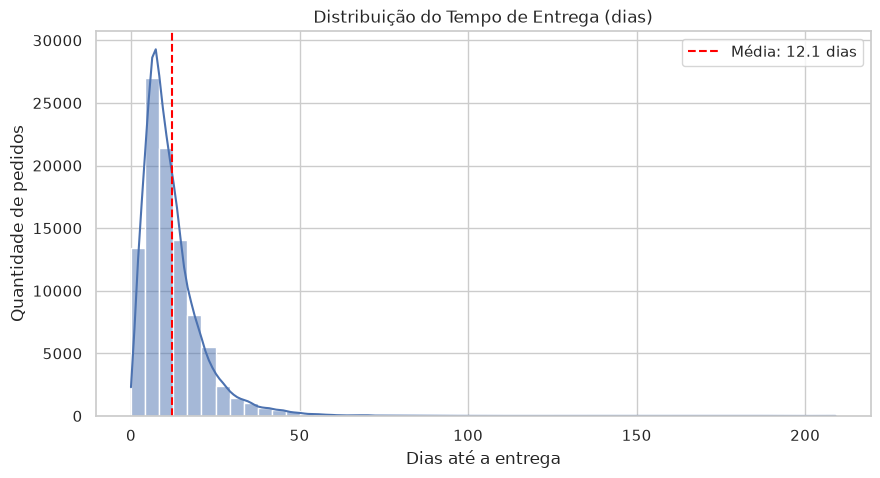

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(delivered['delivery_time_days'], bins=50, kde=True)
plt.title('Distribuição do Tempo de Entrega (dias)')
plt.xlabel('Dias até a entrega')
plt.ylabel('Quantidade de pedidos')
plt.axvline(delivered['delivery_time_days'].mean(), color='red', linestyle='--', label=f"Média: {delivered['delivery_time_days'].mean():.1f} dias")
plt.legend()
plt.show()

In [13]:
delivered['delivery_vs_estimate'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

delivered['on_time'] = delivered['delivery_vs_estimate'] <= 0

pontualidade = delivered['on_time'].value_counts(normalize=True) * 100
print(f"Pedidos entregues no prazo: {pontualidade[True]:.1f}%")
print(f"Enregues com atraso: {pontualidade[False]:.1f}%")

Pedidos entregues no prazo: 93.2%
Enregues com atraso: 6.8%
